This notebook is for the analysis of question 3 in the survey - how well explained is the response?

In [5]:
import logging
from datetime import datetime
from pathlib import Path

"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from analysis_helpers import load_raw, wrap_labels

# PARAMETERS
classifications_csv_path = 'survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = 'survey_responses/analysis/may'
ml_responses_database_path = 'records_bedrock.db'
prompts_database_path = 'records_cajetan.db'
subjects_path = 'survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b'] # Deepseek-r1 was run with two inference platforms. We retain the results for the deepseek model with more parameters for a fair comparison

In [6]:
sns.set_theme(style="darkgrid")

# Load data

In [7]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


In [8]:
combined_final = load_raw(classifications_csv_path, subjects_path, prompts_database_path, exclude_models=exclude_models, exclude_prompt_ids=exclude_prompts, workflow_id=workflow_id)

# Analyse Q3

In [9]:
summary_q3 = combined_final.T3.value_counts()

In [10]:
summary_q3

T3
3 - good                          89
2 - average                       40
1 - poor                          20
4 - expert / better than human    19
Name: count, dtype: int64

In [11]:
# map t2 to numerical values
rating_description_to_number = {"3 - good": 3,
"2 - average": 2,
"1 - poor": 1,
"4 - expert / better than human": 4}

In [17]:
combined_final['T3_score']=combined_final['T3'].apply(lambda x: rating_description_to_number[x])

In [18]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score',
       'T3_score'],
      dtype='object')

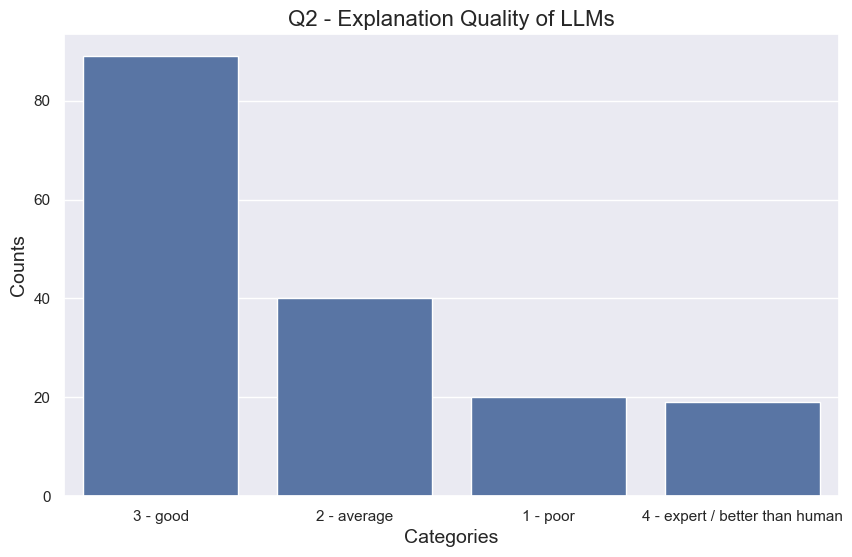

In [19]:
# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_q3.index, y=summary_q3.values)
plt.title('Q2 - Explanation Quality of LLMs',fontsize=16)
plt.xlabel('Categories',fontsize=14)
plt.ylabel('Counts',fontsize=14)
plt.show()

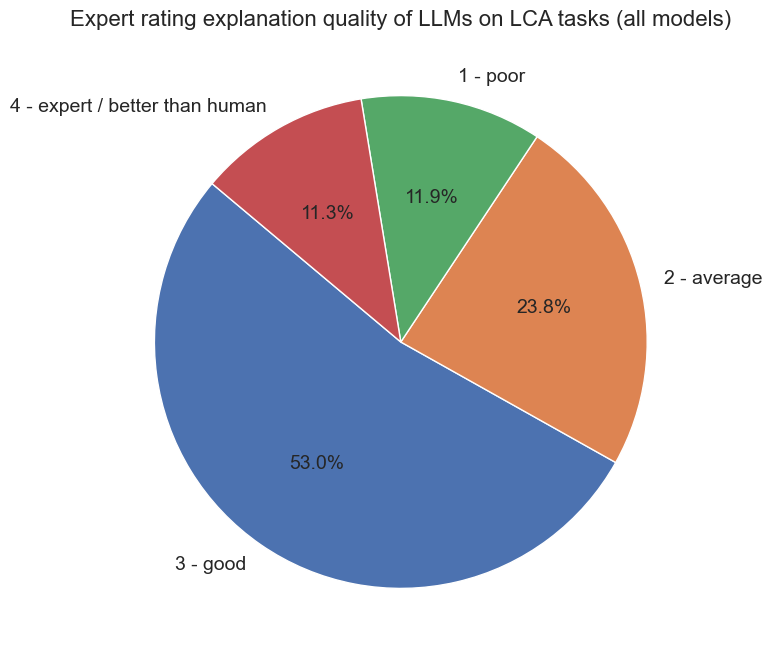

In [20]:
# Pie Chart with larger text
plt.figure(figsize=(8, 8))
plt.pie(summary_q3.values, labels=summary_q3.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Expert rating explanation quality of LLMs on LCA tasks (all models)', fontsize=16)
plt.show()

In [21]:
q2_by_model = combined_final.groupby(['#llm_model', 'T3_score']).size().unstack(fill_value=0)

In [22]:
q2_by_model

T3_score,1,2,3,4
#llm_model,,,,
claude-3.7-sonnet,1,5,8,2
deepseek-r1,5,5,5,1
gemini-2.0-flash,3,1,4,4
google-gemma3,0,3,6,0
llama4-maverick,2,4,9,1
llama4-scout,0,2,6,4
microsoft-phi4,1,4,11,0
mistral-large,1,6,8,1
nova-premier-v1,1,4,9,2


In [23]:
model_T3_mean = combined_final.groupby('#llm_model')['T3_score'].mean().sort_values(ascending=False)
print(model_T3_mean)


#llm_model
llama4-scout         3.166667
openai-gpt-4.1       2.761905
gemini-2.0-flash     2.750000
nova-premier-v1      2.750000
claude-3.7-sonnet    2.687500
google-gemma3        2.666667
microsoft-phi4       2.625000
mistral-large        2.562500
llama4-maverick      2.562500
qwen3                2.500000
deepseek-r1          2.125000
Name: T3_score, dtype: float64


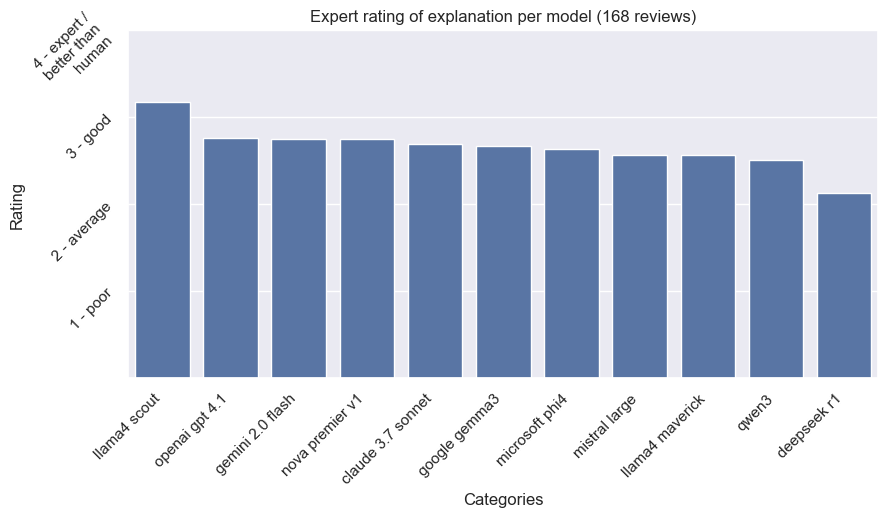

In [46]:



# Count Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_T3_mean.index,y=model_T3_mean.values)
plt.title(f'Expert rating of explanation per model ({combined_final.shape[0]} reviews)')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model.png')
plt.show()



# The same, but take the median

In [25]:
model_T3_median = combined_final.groupby('#llm_model')['T3_score'].median().sort_values(ascending=False)
print(model_T3_mean)


#llm_model
llama4-scout         3.166667
openai-gpt-4.1       2.761905
gemini-2.0-flash     2.750000
nova-premier-v1      2.750000
claude-3.7-sonnet    2.687500
google-gemma3        2.666667
microsoft-phi4       2.625000
mistral-large        2.562500
llama4-maverick      2.562500
qwen3                2.500000
deepseek-r1          2.125000
Name: T3_score, dtype: float64


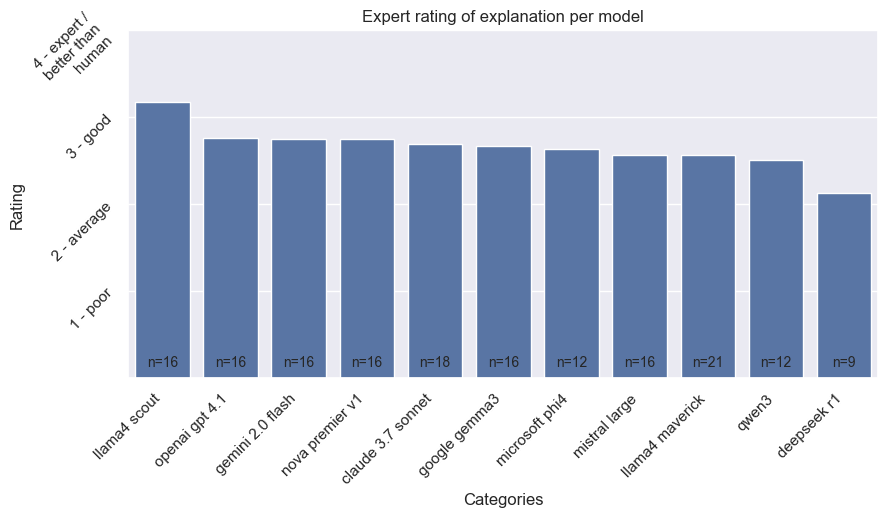

In [50]:

sns.set_theme(style="darkgrid")

# Count Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=model_T3_mean.index,y=model_T3_mean.values)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(list(rating_description_to_number.values()), list(rating_description_to_number.keys()))

# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T3_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)


plt.subplots_adjust(left=0.15, bottom=0.3)
wrap_labels(plt.gca(), width=15)

plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model_median.png')
plt.show()



# Violin plot

In [27]:
# Add count of datapoints per model to combined_df
counts_per_model = combined_final.groupby('#llm_model').T3.agg(len).to_dict()

combined_final['data_points_per_model'] = combined_final['#llm_model'].apply(lambda x: counts_per_model[x])

C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Artur\Documents\Projects (local)\GLAD AI\llm testing\Zooniverse project\.venv\lib\site-packages\seaborn\categorical.py:3399: UserWarn

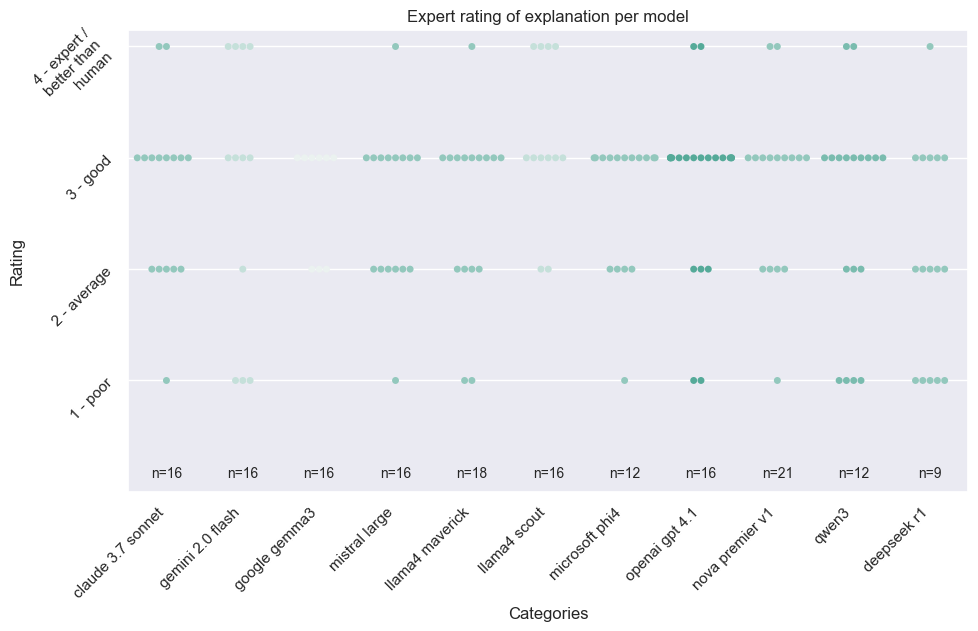

In [28]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys
ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0,'')
# Violin Plot

plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.swarmplot(x='#llm_model', y='T3_score', data=combined_final,order=list(model_T3_median.index),hue='data_points_per_model',palette=colors)
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0,5,1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)


# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T3_score'].count()
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count}', ha='center', va='bottom', fontsize=10)

ax.get_legend().remove()
plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir/f'{current_date}_q2_scientific_explanation_per_model_violin.png')

plt.show()

AttributeError: 'NoneType' object has no attribute 'remove'

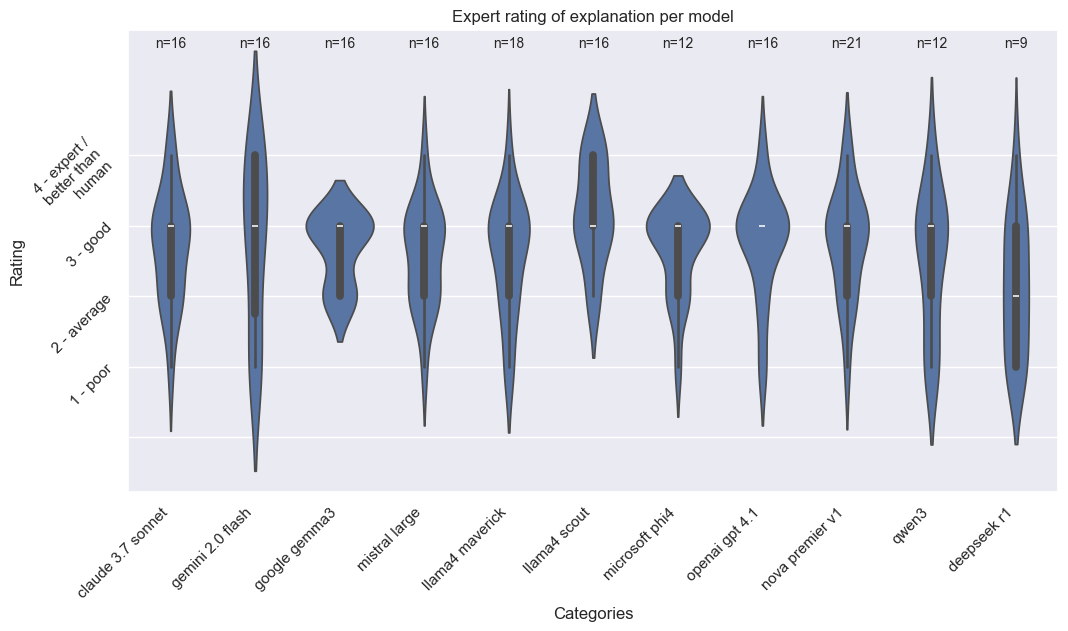

In [43]:
import numpy as np

def convert_dict_to_sorted_list(input_dict):
    # Sort the keys based on their values
    sorted_keys = sorted(input_dict, key=input_dict.get)
    return sorted_keys

ylabels_text = convert_dict_to_sorted_list(rating_description_to_number)
ylabels_text.insert(0, '')

# Whisker Plot
plt.figure(figsize=(12, 6))

colors = sns.color_palette("light:#5A9", as_cmap=True)

ax = sns.violinplot(x='#llm_model', y='T3_score', data=combined_final, order=list(model_T3_median.index))
plt.title('Expert rating of explanation per model')
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.yticks(np.arange(0, 5, 1), ylabels_text)

# Rotate x-tick labels and adjust alignment
plt.xticks(rotation=45, ha='right')
wrap_labels(plt.gca(), width=15)

# Add number of data points to each bar
for i, model in enumerate(combined_final['#llm_model'].unique()):
    count = combined_final[combined_final['#llm_model'] == model]['T3_score'].count()
    ax.text(i, ax.get_ylim()[1] - 0.1, f'n={count}', ha='center', va='top', fontsize=10)

plt.subplots_adjust(left=0.15, right=0.85)
plt.savefig(output_dir / f'{current_date}_q2_scientific_explanation_per_model_whisker.png')

plt.show()

In [30]:
ylabels_text

['', '1 - poor', '2 - average', '3 - good', '4 - expert / better than human']

# Analyse textual remarks in comment field for Q3

In [31]:
combined_final.T8.drop_duplicates()

0                                      Clear explanation
1                                                       
2      well explained, but it could have been explain...
3      There seems to be a missing part between page ...
4      General infromation is provided, but limited i...
5                        Answer is justified very poorly
7      misses reference to allocation hierachy and IS...
8      The answer is correct and skematic in does not...
9      the answer is detailed and correct even though...
11                  The answer is exhaustive and correct
12                    the answer is not well articulated
13     There are significant missing details. Also be...
14     The answer contains all the information requir...
15     The explanation is someway general without any...
16                 The reasoning is clear in interesting
17     Very good response analysing the difference be...
18                The answer is well explained and clear
19                     The answ

In [32]:

from wordcloud import  WordCloud
import multidict
import re

def get_frequency_dict_for_text(sentence):
    fullTermsDict = multidict.MultiDict()
    tmpDict = {}

    # making dict for counting frequencies
    for text in sentence.split(" "):
        if re.match("a|the|an|the|to|in|for|of|or|by|with|is|on|that|be|answer|response|but|not|it|\.|,", text):
            continue
        val = tmpDict.get(text, 0)
        tmpDict[text.lower()] = val + 1
    for key in tmpDict:
        fullTermsDict.add(key, tmpDict[key])
    return fullTermsDict



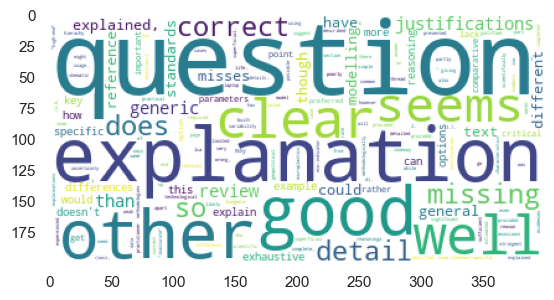

In [33]:
# Join all answers to get a single piece of text
all_answers_text=' '.join(combined_final.T8.drop_duplicates().to_list())

# Custom frequencies calculation
all_answers_frequencies = get_frequency_dict_for_text(all_answers_text)

# Create wordcloud
wordcloud_obj = WordCloud(background_color="white")
wordcloud_obj.generate_from_frequencies(all_answers_frequencies)

plt.grid(visible=False,which='both',axis='both')
plt.imshow(wordcloud_obj)
plt.show()

In [34]:
plt.show()

In [35]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
q3_extra_comments = combined_final.loc[:,'T8'].drop_duplicates()
q3_extra_comments = pd.DataFrame({'response_id':q3_extra_comments.index,'comment':q3_extra_comments.values})

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Artur\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [36]:
get_sentiment_nltk_vader = lambda x: sia.polarity_scores(x)['compound']
q3_extra_comments['sentiment_vader_simple'] = q3_extra_comments.comment.dropna().map(get_sentiment_nltk_vader)

In [37]:
q3_extra_comments

,response_id,comment,sentiment_vader_simple
0,0,Clear explanation,0.3818
1,1,,0.0000
2,2,"well explained, but it could have been explain...",0.1406
3,3,There seems to be a missing part between page ...,-0.6486
4,4,"General infromation is provided, but limited i...",-0.3291
5,5,Answer is justified very poorly,0.4019
6,7,misses reference to allocation hierachy and IS...,-0.2263
7,8,The answer is correct and skematic in does not...,0.0000
8,9,the answer is detailed and correct even though...,-0.4404
9,11,The answer is exhaustive and correct,-0.1280


In [38]:
# Sentiment using FLAIR https://github.com/flairNLP/flair
# Flair gives better quality sentiment analyses on this type of dataset than VADER, as it is trained on longer-form movie reviews whereas NLTK's VADER is trained on short-form informal social media posts
from flair.data import Sentence
from flair.nn import Classifier

# load the NER tagger
tagger = Classifier.load('sentiment')


In [39]:
def get_sentiment_flair(x, tagger):
    sentence = Sentence(x)
    tagger.predict(sentence)
    return pd.Series([sentence.get_label().value, sentence.get_label().score])
q3_extra_comments[['sentiment_flair_label','sentiment_flair_confidence']] = q3_extra_comments.comment.dropna().apply(get_sentiment_flair,tagger=tagger)

2025-06-19 11:19:35,090 Warning: An empty Sentence was created! Are there empty strings in your dataset?


In [40]:
q3_extra_comments

,response_id,comment,sentiment_vader_simple,sentiment_flair_label,sentiment_flair_confidence
0,0,Clear explanation,0.3818,POSITIVE,0.999482
1,1,,0.0000,O,1.000000
2,2,"well explained, but it could have been explain...",0.1406,NEGATIVE,0.707711
3,3,There seems to be a missing part between page ...,-0.6486,NEGATIVE,0.998553
4,4,"General infromation is provided, but limited i...",-0.3291,NEGATIVE,0.999235
5,5,Answer is justified very poorly,0.4019,NEGATIVE,0.998016
6,7,misses reference to allocation hierachy and IS...,-0.2263,NEGATIVE,0.999423
7,8,The answer is correct and skematic in does not...,0.0000,NEGATIVE,0.999626
8,9,the answer is detailed and correct even though...,-0.4404,POSITIVE,0.999258
9,11,The answer is exhaustive and correct,-0.1280,POSITIVE,0.996954


In [41]:
sns. q3_extra_comments.sentiment_flair_label

AttributeError: module 'seaborn' has no attribute 'q3_extra_comments'

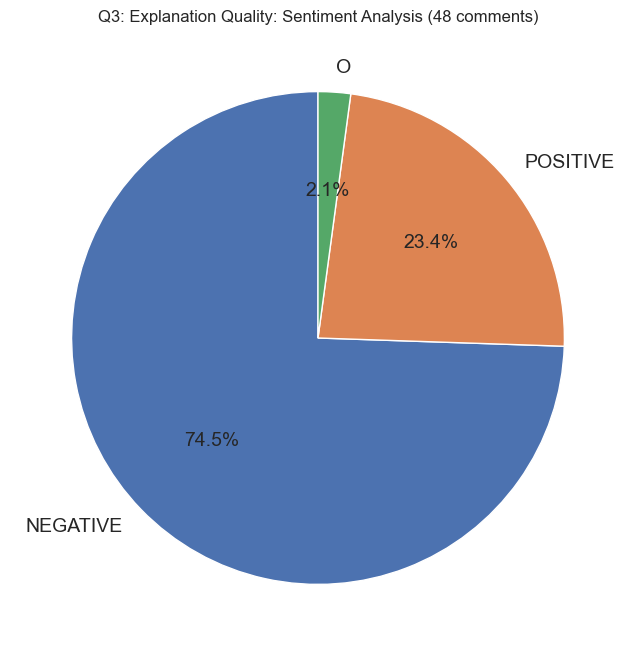

In [190]:
plt.figure(figsize=(8, 8))
sentiment_pivot = q3_extra_comments.sentiment_flair_label.value_counts()
plt.pie(sentiment_pivot, labels=sentiment_pivot.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14})
plt.title(f'Q3: Explanation Quality: Sentiment Analysis ({q3_extra_comments.shape[0]} comments)')
plt.show()